In [1]:
import pandas as pd
import requests
import numpy as np

In [19]:
#ETL----------------------------------------------------------------------------------------------
gasolina = pd.read_csv(r"C:\Users\guire\OneDrive\Área de Trabalho\gasxbrent\gasC.csv", sep =";")
print(gasolina.head())

       MÊ           PRODUTO PREÇO MÉDIO REVEN  Unnamed: 3  Unnamed: 4  \
0  jan/13  ETANOL HIDRATADO             1,956         NaN         NaN   
1  jan/13    GASOLINA COMUM             2,763         NaN         NaN   
2  jan/13               GLP            40,164         NaN         NaN   
3  jan/13               GNV             1,764         NaN         NaN   
4  jan/13       OLEO DIESEL             2,156         NaN         NaN   

   Unnamed: 5  Unnamed: 6  Unnamed: 7  Unnamed: 8  Unnamed: 9  Unnamed: 10  \
0         NaN         NaN         NaN         NaN         NaN          NaN   
1         NaN         NaN         NaN         NaN         NaN          NaN   
2         NaN         NaN         NaN         NaN         NaN          NaN   
3         NaN         NaN         NaN         NaN         NaN          NaN   
4         NaN         NaN         NaN         NaN         NaN          NaN   

   Unnamed: 11  Unnamed: 12  Unnamed: 13  Unnamed: 14  
0          NaN          NaN         

In [32]:
gasolina = pd.read_csv(
    r"C:\Users\guire\OneDrive\Área de Trabalho\gasxbrent\gasC.csv",
    sep=";"
)

gasolina = gasolina[['MÊ', 'PRODUTO', 'PREÇO MÉDIO REVEN']].copy()
gasolina.columns = ['mes', 'produto', 'gas_price_brl']

gasolina = gasolina[gasolina['produto'] == 'GASOLINA COMUM'].copy()

gasolina['gas_price_brl'] = (
    gasolina['gas_price_brl']
    .astype(str)
    .str.replace(',', '.')
    .astype(float)
)

meses = {
    'jan': 'Jan', 'fev': 'Feb', 'mar': 'Mar',
    'abr': 'Apr', 'mai': 'May', 'jun': 'Jun',
    'jul': 'Jul', 'ago': 'Aug', 'set': 'Sep',
    'out': 'Oct', 'nov': 'Nov', 'dez': 'Dec'
}

gasolina['mes'] = gasolina['mes'].replace(meses, regex=True)
gasolina['mes'] = pd.to_datetime(gasolina['mes'], format='%b/%y')

print(gasolina.head())
print(gasolina.dtypes)



          mes         produto  gas_price_brl
1  2013-01-01  GASOLINA COMUM          2.763
7  2013-02-01  GASOLINA COMUM          2.887
13 2013-03-01  GASOLINA COMUM          2.886
19 2013-04-01  GASOLINA COMUM          2.876
25 2013-05-01  GASOLINA COMUM          2.862
mes              datetime64[ns]
produto                  object
gas_price_brl           float64
dtype: object


In [9]:
print(gasolina.head())

          mes         produto  preco_medio_revenda
1  2013-01-01  GASOLINA COMUM                2.763
7  2013-02-01  GASOLINA COMUM                2.887
13 2013-03-01  GASOLINA COMUM                2.886
19 2013-04-01  GASOLINA COMUM                2.876
25 2013-05-01  GASOLINA COMUM                2.862


In [11]:
brent = pd.read_csv(r"C:\Users\guire\OneDrive\Área de Trabalho\gasxbrent\brent.csv")
print(brent.head())

  observation_date  POILBREUSDM
0       2013-01-01   112.527826
1       2013-02-01   116.488000
2       2013-03-01   109.585714
3       2013-04-01   102.960000
4       2013-05-01   102.980435


In [12]:
brent = brent.rename(columns={
    'observation_date': 'mes',
    'POILBREUSDM' : 'brent_price_usd'})

print(brent.head())

          mes  brent_price_usd
0  2013-01-01       112.527826
1  2013-02-01       116.488000
2  2013-03-01       109.585714
3  2013-04-01       102.960000
4  2013-05-01       102.980435


In [13]:
url1 = "https://api.bcb.gov.br/dados/serie/bcdata.sgs.1/dados?formato=json&dataInicial=01/01/2013&dataFinal=31/12/2022"
url2 = "https://api.bcb.gov.br/dados/serie/bcdata.sgs.1/dados?formato=json&dataInicial=01/01/2023&dataFinal=31/12/2026"

res1 = requests.get(url1, timeout=30)
res2 = requests.get(url2, timeout=30)

print("Status 1:", res1.status_code)
print("Status 2:", res2.status_code)

print("Texto 1:", res1.text[:200])
print("Texto 2:", res2.text[:200])

Status 1: 200
Status 2: 200
Texto 1: [{"data":"02/01/2013","valor":"2.0415"},{"data":"03/01/2013","valor":"2.0464"},{"data":"04/01/2013","valor":"2.0425"},{"data":"07/01/2013","valor":"2.0312"},{"data":"08/01/2013","valor":"2.0286"},{"da
Texto 2: [{"data":"02/01/2023","valor":"5.3436"},{"data":"03/01/2023","valor":"5.3759"},{"data":"04/01/2023","valor":"5.4459"},{"data":"05/01/2023","valor":"5.4026"},{"data":"06/01/2023","valor":"5.2855"},{"da


In [14]:
dados1 = res1.json()
dados2 = res2.json()

cambio = pd.concat([
    pd.DataFrame(dados1),
    pd.DataFrame(dados2)
], ignore_index=True)

cambio['data'] = pd.to_datetime(cambio['data'], dayfirst=True)
cambio['valor'] = cambio['valor'].astype(float)
cambio = cambio.drop_duplicates()

cambio_mensal = (
    cambio
    .set_index('data')
    .resample('ME')
    .mean()
    .reset_index()
)

cambio_mensal['data'] = cambio_mensal['data'].dt.to_period('M').dt.to_timestamp()

cambio_mensal = cambio_mensal.rename(columns={
    'data': 'mes',
    'valor': 'usd_brl'
})

print(cambio_mensal.head())
print(brent.head())

         mes   usd_brl
0 2013-01-01  2.031077
1 2013-02-01  1.973250
2 2013-03-01  1.982840
3 2013-04-01  2.002214
4 2013-05-01  2.034843
          mes  brent_price_usd
0  2013-01-01       112.527826
1  2013-02-01       116.488000
2  2013-03-01       109.585714
3  2013-04-01       102.960000
4  2013-05-01       102.980435


In [15]:
brent['mes'] = pd.to_datetime(brent['mes'])
brent = brent.merge(cambio_mensal,on='mes')

In [21]:
brent = brent[['mes','brent_price_usd','usd_brl']]
brent['brent_brl'] = brent['brent_price_usd'] * brent['usd_brl'] 

In [22]:
print(brent.head())

         mes  brent_price_usd   usd_brl   brent_brl
0 2013-01-01       112.527826  2.031077  228.552710
1 2013-02-01       116.488000  1.973250  229.859946
2 2013-03-01       109.585714  1.982840  217.290938
3 2013-04-01       102.960000  2.002214  206.147916
4 2013-05-01       102.980435  2.034843  209.549002


In [33]:
df = gasolina.merge(brent,on="mes")


In [34]:
print(df.head())

         mes         produto  gas_price_brl  brent_price_usd   usd_brl  \
0 2013-01-01  GASOLINA COMUM          2.763       112.527826  2.031077   
1 2013-02-01  GASOLINA COMUM          2.887       116.488000  1.973250   
2 2013-03-01  GASOLINA COMUM          2.886       109.585714  1.982840   
3 2013-04-01  GASOLINA COMUM          2.876       102.960000  2.002214   
4 2013-05-01  GASOLINA COMUM          2.862       102.980435  2.034843   

    brent_brl  
0  228.552710  
1  229.859946  
2  217.290938  
3  206.147916  
4  209.549002  


In [20]:
#-----------------------------------------------------------------------------------------------------------------------


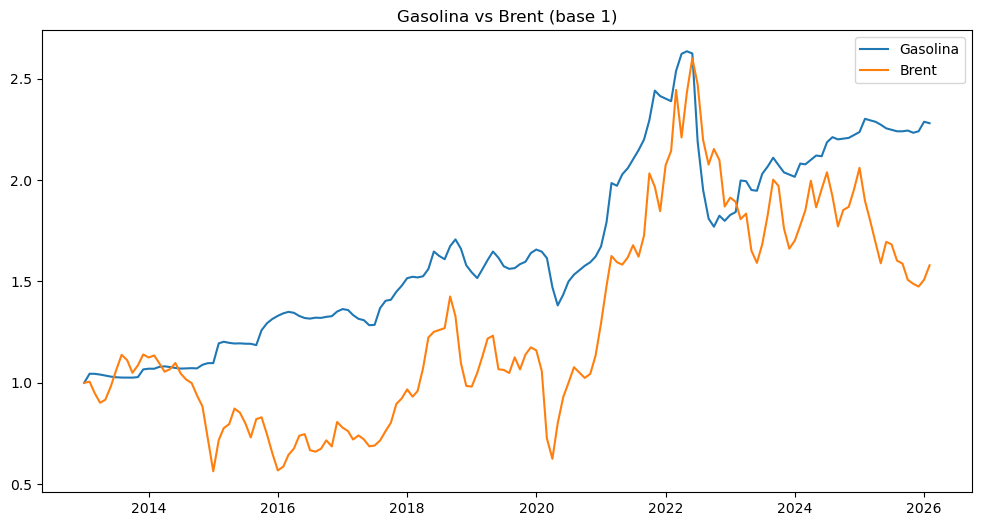

In [41]:
import matplotlib.pyplot as plt

df['gasolina_norm'] = df['gas_price_brl'] / df['gas_price_brl'].iloc[0] #normalizacao
df['brent_norm'] = df['brent_brl'] / df['brent_brl'].iloc[0]

plt.figure(figsize=(12,6))

plt.plot(df['mes'], df['gasolina_norm'], label='Gasolina')
plt.plot(df['mes'], df['brent_norm'], label='Brent')

plt.legend()
plt.title('Gasolina vs Brent (base 1)')
plt.show()




In [51]:
import statsmodels.api as sm

X = df[['brent_brl']]
X = sm.add_constant(X)

y = df['gas_price_brl']

modelo = sm.OLS(y, X).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:          gas_price_brl   R-squared:                       0.728
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     414.2
Date:                Sat, 28 Mar 2026   Prob (F-statistic):           1.24e-45
Time:                        21:29:35   Log-Likelihood:                -153.74
No. Observations:                 157   AIC:                             311.5
Df Residuals:                     155   BIC:                             317.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.8455      0.144     12.809      0.0

In [52]:
modelo = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags':1})

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:          gas_price_brl   R-squared:                       0.728
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     264.6
Date:                Sat, 28 Mar 2026   Prob (F-statistic):           2.43e-35
Time:                        21:38:02   Log-Likelihood:                -153.74
No. Observations:                 157   AIC:                             311.5
Df Residuals:                     155   BIC:                             317.6
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.8455      0.177     10.443      0.0